# Temporal Mamba Hyperparameter Tuning on `tgbn-trade`

This notebook builds on `temporal_mamba_diagnostics.ipynb` and turns the same training path into a resumable hyperparameter search workflow for the temporal Mamba sheaf model.

It is designed to stay efficient by:
- reusing the repo's existing temporal data/model helpers
- caching snapshot builds for each candidate timestamp window
- pruning weak trials early with Optuna
- using smaller search budgets before a final retrain/evaluation pass
- persisting the study to SQLite so interrupted searches can resume


## Environment notes

This notebook expects the same environment as `exp/run_temporal.py`, plus `optuna` for the study loop.

If `optuna` is missing in your kernel, run:

```python
%pip install optuna
```


In [1]:
import sys
print(sys.executable)

/home/zhuowez1/miniconda3/envs/nsd/bin/python


In [2]:
import copy
import gc
import math
import os
import random
import sys
import time
from pathlib import Path
from unittest.mock import patch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from tqdm.auto import tqdm
from torch_geometric.utils import coalesce, remove_self_loops, to_undirected

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'exp').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'exp').exists(), 'Run this notebook from the repo root or notebooks/.'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.temporal_utils import build_temporal_snapshots
from models.mamba_models import MambaSheafDiffusion

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
torch.set_printoptions(sci_mode=False)


def _require_optuna():
    try:
        import optuna
    except ImportError as exc:
        raise RuntimeError(
            'This notebook requires Optuna, but the active kernel cannot import it. '
            f'Current interpreter: {sys.executable}. '
            'Install Optuna into this exact interpreter or switch the notebook kernel, then rerun the setup cells.'
        ) from exc
    return optuna


def _seed_everything(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def pytest_importorskip(module_name):
    try:
        __import__(module_name)
    except Exception as exc:
        raise RuntimeError(
            f"Required temporal dependency {module_name!r} is unavailable. "
            'Install the optional TGB dependencies before running this notebook.'
        ) from exc
    return sys.modules[module_name]


def _load_tgb_dataset(dataset_name):
    root = os.environ.get('TGB_ROOT', 'datasets')
    answer = 'y' if os.environ.get('TGB_DOWNLOAD') == '1' else 'n'
    tgb_dataset = pytest_importorskip('tgb.nodeproppred.dataset_pyg')
    pytest_importorskip('tgb.nodeproppred.evaluate')
    with patch('builtins.input', return_value=answer):
        return tgb_dataset.PyGNodePropPredDataset(name=dataset_name, root=root)


def _load_temporal_data(dataset_name):
    dataset = _load_tgb_dataset(dataset_name)
    temporal_data = dataset.get_TemporalData()
    return dataset, temporal_data


def _make_node_features(dataset, num_nodes, seed=43):
    try:
        if hasattr(dataset, 'node_feat') and dataset.node_feat is not None and dataset.node_feat.size(0) == num_nodes:
            return dataset.node_feat.float()
    except (AttributeError, RuntimeError):
        pass

    feature_dim = int(os.environ.get('TGB_NODE_FEATURE_DIM', 64))
    generator = torch.Generator().manual_seed(seed)
    return torch.randn(num_nodes, feature_dim, generator=generator)


def _normalize_sheaf_edge_index(edge_index):
    edge_index, _ = remove_self_loops(edge_index)
    edge_index = to_undirected(edge_index)
    edge_index, _ = coalesce(edge_index, None)
    return edge_index.contiguous()


def _make_model_from_config(edge_index, x, num_nodes, output_dim, device, config):
    model_args = {
        'd': int(config['d']),
        'add_lp': False,
        'add_hp': False,
        'device': device,
        'graph_size': num_nodes,
        'layers': int(config['layers']),
        'normalised': True,
        'deg_normalised': False,
        'linear': False,
        'input_dropout': 0.0,
        'dropout': float(config['dropout']),
        'left_weights': True,
        'right_weights': True,
        'sparse_learner': False,
        'use_act': True,
        'input_dim': int(x.size(1)),
        'hidden_channels': int(config['hidden_channels']),
        'output_dim': int(output_dim),
        'sheaf_act': 'tanh',
        'second_linear': False,
        'orth': 'householder',
        'edge_weights': False,
        'max_t': 1.0,
        'stateful_temporal': bool(config['stateful_temporal']),
        'closure_hops': int(config['closure_hops']),
        'temporal_d_model': int(config['temporal_d_model']),
    }
    return MambaSheafDiffusion(_normalize_sheaf_edge_index(edge_index).to(device), model_args).to(device)


def _split_edge_ids(dataset, temporal_data):
    if all(hasattr(dataset, name) for name in ('train_mask', 'val_mask', 'test_mask')):
        train_edge_ids = dataset.train_mask.nonzero(as_tuple=False).view(-1)
        val_edge_ids = dataset.val_mask.nonzero(as_tuple=False).view(-1)
        test_edge_ids = dataset.test_mask.nonzero(as_tuple=False).view(-1)
        split_source = 'official_tgb_masks'
    else:
        total_edges = len(temporal_data.src)
        train_edge_ids = torch.arange(0, total_edges // 2)
        val_edge_ids = torch.arange(total_edges // 2, (total_edges * 3) // 4)
        test_edge_ids = torch.arange((total_edges * 3) // 4, total_edges)
        split_source = 'fallback_contiguous_50_25_25'
    return train_edge_ids, val_edge_ids, test_edge_ids, split_source


def _build_snapshots(temporal_data, edge_ids, node_features, max_edges=None, time_window=None):
    return build_temporal_snapshots(
        temporal_data.src,
        temporal_data.dst,
        temporal_data.t,
        node_features,
        edge_ids=edge_ids,
        max_edges=max_edges,
        time_window=time_window,
    )


def _node_label_batches(dataset, snapshots):
    dataset.reset_label_time()
    batches = []
    for snapshot in snapshots:
        cur_t = int(snapshot.timestamp.item()) if torch.is_tensor(snapshot.timestamp) else int(snapshot.timestamp)
        label_tuple = dataset.get_node_label(cur_t)
        if label_tuple is None:
            continue
        _, label_srcs, labels = label_tuple
        batches.append((snapshot, label_srcs.long(), labels.float()))
    return batches


def _build_supervised_snapshots(dataset, temporal_data, edge_ids, node_features, max_edges=None, time_window=None, split_name='split'):
    if max_edges is None:
        selected_edge_ids = edge_ids
    else:
        selected_edge_ids = edge_ids[:max_edges]

    if selected_edge_ids.numel() == 0:
        return [], selected_edge_ids

    while True:
        snapshots = _build_snapshots(
            temporal_data,
            selected_edge_ids,
            node_features,
            max_edges=None,
            time_window=time_window,
        )
        if _node_label_batches(dataset, snapshots):
            return snapshots, selected_edge_ids

        if selected_edge_ids.numel() >= edge_ids.numel():
            raise RuntimeError(
                f'{split_name} split produced no label-supervised snapshots even after expanding to all {edge_ids.numel()} available edges.'
            )

        next_count = min(edge_ids.numel(), max(selected_edge_ids.numel() * 2, selected_edge_ids.numel() + 1))
        selected_edge_ids = edge_ids[:next_count]


def _canonical_time_window(window):
    if window is None or pd.isna(window):
        return None
    return int(window)


def _normalize_window_candidates(window_candidates):
    normalized = []
    seen = set()
    for window in window_candidates:
        value = _canonical_time_window(window)
        if value is not None and value <= 0:
            continue
        if value in seen:
            continue
        seen.add(value)
        normalized.append(value)
    numeric = sorted(window for window in normalized if window is not None)
    return ([None] if None in seen else []) + numeric


def _make_window_candidates(timestamps, edge_ids, manual_candidates=None, limit=12):
    if manual_candidates is not None:
        return _normalize_window_candidates(manual_candidates)
    if edge_ids.numel() == 0:
        return [None]

    selected_ts = timestamps[edge_ids]
    span = int((selected_ts.max() - selected_ts.min()).item()) if selected_ts.numel() > 0 else 0
    if span <= 1:
        return [None, 1]

    raw = np.geomspace(1, span, num=limit)
    candidates = [None] + [int(x) for x in np.unique(np.round(raw).astype(int)).tolist() if int(x) > 0]
    return _normalize_window_candidates(candidates)


def _estimate_snapshot_bucket_stats(timestamps, edge_ids, time_window=None, max_edges=None):
    selected_edge_ids = edge_ids if max_edges is None else edge_ids[:max_edges]
    if selected_edge_ids.numel() == 0:
        return {
            'edge_prefix': 0,
            'raw_unique_timestamps': 0,
            'estimated_snapshots': 0,
            'estimated_mean_edges': float('nan'),
            'estimated_max_edges': 0,
            'estimated_min_edges': 0,
            'compression_ratio': float('nan'),
            'timestamp_start': None,
            'timestamp_end': None,
            'representative_timestamps': torch.empty(0, dtype=timestamps.dtype),
        }

    selected_ts = timestamps[selected_edge_ids]
    ordered_ts = selected_ts[torch.argsort(selected_ts)]
    raw_unique_timestamps = int(torch.unique_consecutive(ordered_ts).numel())

    if time_window is None:
        bucket_keys = ordered_ts
    else:
        if time_window <= 0:
            raise ValueError('time_window must be positive when provided.')
        bucket_keys = torch.div(ordered_ts - ordered_ts[0], time_window, rounding_mode='floor')

    _, bucket_counts = torch.unique_consecutive(bucket_keys, return_counts=True)
    bucket_end_indices = torch.cumsum(bucket_counts, dim=0) - 1
    representative_timestamps = ordered_ts[bucket_end_indices]

    return {
        'edge_prefix': int(selected_edge_ids.numel()),
        'raw_unique_timestamps': raw_unique_timestamps,
        'estimated_snapshots': int(bucket_counts.numel()),
        'estimated_mean_edges': float(bucket_counts.float().mean().item()),
        'estimated_max_edges': int(bucket_counts.max().item()),
        'estimated_min_edges': int(bucket_counts.min().item()),
        'compression_ratio': float(bucket_counts.numel() / raw_unique_timestamps) if raw_unique_timestamps else float('nan'),
        'timestamp_start': int(ordered_ts[0].item()),
        'timestamp_end': int(ordered_ts[-1].item()),
        'representative_timestamps': representative_timestamps,
    }


def _has_label_at_snapshot_timestamps(dataset, snapshot_timestamps):
    dataset.reset_label_time()
    first_label_ts = None
    for ts in snapshot_timestamps.tolist():
        label_tuple = dataset.get_node_label(int(ts))
        if label_tuple is not None:
            first_label_ts = int(ts)
            break
    return first_label_ts is not None, first_label_ts


def _estimate_supervised_prefix(dataset, temporal_data, edge_ids, max_edges=None, time_window=None):
    selected_count = int(edge_ids.numel()) if max_edges is None else min(int(max_edges), int(edge_ids.numel()))
    if selected_count == 0:
        stats = _estimate_snapshot_bucket_stats(temporal_data.t, edge_ids, time_window=time_window, max_edges=0)
        stats.update({'has_label_supervision': False, 'first_label_timestamp': None})
        return stats

    while True:
        stats = _estimate_snapshot_bucket_stats(
            temporal_data.t,
            edge_ids,
            time_window=time_window,
            max_edges=selected_count,
        )
        has_label_supervision, first_label_timestamp = _has_label_at_snapshot_timestamps(
            dataset,
            stats['representative_timestamps'],
        )
        stats.update({
            'has_label_supervision': has_label_supervision,
            'first_label_timestamp': first_label_timestamp,
        })
        if has_label_supervision or selected_count >= int(edge_ids.numel()):
            return stats
        selected_count = min(int(edge_ids.numel()), max(selected_count * 2, selected_count + 1))


def _estimate_time_window_grid(dataset, temporal_data, edge_ids, max_edges, candidate_windows):
    rows = []
    for time_window in candidate_windows:
        stats = _estimate_supervised_prefix(
            dataset,
            temporal_data,
            edge_ids,
            max_edges=max_edges,
            time_window=time_window,
        )
        rows.append({
            'time_window': time_window,
            'window_label': 'exact timestamps' if time_window is None else str(time_window),
            'edge_prefix': stats['edge_prefix'],
            'raw_unique_timestamps': stats['raw_unique_timestamps'],
            'estimated_snapshots': stats['estimated_snapshots'],
            'estimated_mean_edges': stats['estimated_mean_edges'],
            'estimated_max_edges': stats['estimated_max_edges'],
            'estimated_min_edges': stats['estimated_min_edges'],
            'compression_ratio': stats['compression_ratio'],
            'timestamp_start': stats['timestamp_start'],
            'timestamp_end': stats['timestamp_end'],
            'has_label_supervision': stats['has_label_supervision'],
            'first_label_timestamp': stats['first_label_timestamp'],
        })
    return pd.DataFrame(rows)


def _recommend_time_window(estimate_df, target_max_snapshots=None, target_max_mean_edges=None):
    if estimate_df.empty:
        return None

    feasible = estimate_df.copy()
    feasible = feasible[feasible['has_label_supervision']]
    if target_max_snapshots is not None:
        feasible = feasible[feasible['estimated_snapshots'] <= target_max_snapshots]
    if target_max_mean_edges is not None:
        feasible = feasible[feasible['estimated_mean_edges'] <= target_max_mean_edges]
    if feasible.empty:
        return None

    order = feasible['time_window'].map(lambda x: -1 if _canonical_time_window(x) is None else _canonical_time_window(x))
    return feasible.iloc[order.argsort(kind='stable')].iloc[0].to_dict()


def _choose_search_windows(estimate_df, recommendation=None, max_windows=4):
    if estimate_df.empty:
        return [None]

    feasible = estimate_df[estimate_df['has_label_supervision']].copy()
    if feasible.empty:
        return [None]

    feasible = feasible.sort_values(
        by=['estimated_snapshots', 'estimated_mean_edges', 'time_window'],
        key=lambda series: series.map(lambda x: -1 if _canonical_time_window(x) is None else _canonical_time_window(x)) if series.name == 'time_window' else series,
    )

    picked = []
    if recommendation is not None:
        picked.append(_canonical_time_window(recommendation['time_window']))

    exact_rows = feasible[feasible['time_window'].isna()]
    if not exact_rows.empty:
        picked.append(None)

    for value in feasible['time_window'].tolist():
        picked.append(_canonical_time_window(value))
        if len(_normalize_window_candidates(picked)) >= max_windows:
            break

    return _normalize_window_candidates(picked)[:max_windows]


def _summarize_snapshots(dataset, snapshots):
    label_batches = _node_label_batches(dataset, snapshots)
    label_counts = [int(labels.size(0)) for _, _, labels in label_batches]
    edge_counts = [int(snapshot.src.numel()) for snapshot in snapshots]
    active_counts = [int(snapshot.active_nodes.numel()) for snapshot in snapshots]
    timestamps = [int(snapshot.timestamp.item()) for snapshot in snapshots]
    return {
        'snapshots': len(snapshots),
        'snapshots_with_labels': len(label_batches),
        'mean_edges': float(np.mean(edge_counts)) if edge_counts else float('nan'),
        'max_edges': int(max(edge_counts)) if edge_counts else 0,
        'mean_active_nodes': float(np.mean(active_counts)) if active_counts else float('nan'),
        'mean_labels': float(np.mean(label_counts)) if label_counts else float('nan'),
        'first_timestamp': min(timestamps) if timestamps else None,
        'last_timestamp': max(timestamps) if timestamps else None,
    }


def _build_snapshot_bundle(dataset, temporal_data, node_features, split_edge_ids, split_caps, time_window):
    train_snapshots, train_ids = _build_supervised_snapshots(
        dataset,
        temporal_data,
        split_edge_ids['train'],
        node_features,
        max_edges=split_caps['train'],
        time_window=time_window,
        split_name='train',
    )
    val_snapshots, val_ids = _build_supervised_snapshots(
        dataset,
        temporal_data,
        split_edge_ids['val'],
        node_features,
        max_edges=split_caps['val'],
        time_window=time_window,
        split_name='validation',
    )
    test_snapshots, test_ids = _build_supervised_snapshots(
        dataset,
        temporal_data,
        split_edge_ids['test'],
        node_features,
        max_edges=split_caps['test'],
        time_window=time_window,
        split_name='test',
    )
    return {
        'time_window': time_window,
        'train_snapshots': train_snapshots,
        'val_snapshots': val_snapshots,
        'test_snapshots': test_snapshots,
        'train_edge_count': int(train_ids.numel()),
        'val_edge_count': int(val_ids.numel()),
        'test_edge_count': int(test_ids.numel()),
    }


def _snapshot_cache_table(dataset, cache):
    rows = []
    for time_window, bundle in cache.items():
        train_summary = _summarize_snapshots(dataset, bundle['train_snapshots'])
        val_summary = _summarize_snapshots(dataset, bundle['val_snapshots'])
        test_summary = _summarize_snapshots(dataset, bundle['test_snapshots'])
        rows.append({
            'time_window': time_window,
            'window_label': 'exact timestamps' if time_window is None else str(time_window),
            'train_edges': bundle['train_edge_count'],
            'train_snapshots': train_summary['snapshots'],
            'train_mean_edges': train_summary['mean_edges'],
            'train_labelled_snapshots': train_summary['snapshots_with_labels'],
            'val_edges': bundle['val_edge_count'],
            'val_snapshots': val_summary['snapshots'],
            'val_labelled_snapshots': val_summary['snapshots_with_labels'],
            'test_edges': bundle['test_edge_count'],
            'test_snapshots': test_summary['snapshots'],
            'test_labelled_snapshots': test_summary['snapshots_with_labels'],
        })
    return pd.DataFrame(rows).sort_values(by=['train_snapshots', 'val_snapshots', 'test_snapshots']).reset_index(drop=True)


def _node_property_loss(outputs, dataset, snapshots):
    from torch.nn import functional as F

    losses = []
    batches = _node_label_batches(dataset, snapshots)
    batch_index = 0
    for snapshot_index, snapshot in enumerate(snapshots):
        if batch_index >= len(batches):
            break
        batch_snapshot, label_srcs, labels = batches[batch_index]
        if batch_snapshot is not snapshot:
            continue
        logits = outputs[snapshot_index]
        pred = logits.index_select(0, label_srcs.to(logits.device))
        target = labels.to(logits.device)
        target = target / target.sum(dim=-1, keepdim=True).clamp_min(1e-12)
        losses.append(-(target * F.log_softmax(pred, dim=-1)).sum(dim=-1).mean())
        batch_index += 1

    if not losses:
        return torch.tensor(0.0, device=outputs[0].device if outputs else 'cpu')
    return torch.stack(losses).mean()


def _next_snapshot_labels(dataset, snapshot):
    cur_t = int(snapshot.timestamp.item()) if torch.is_tensor(snapshot.timestamp) else int(snapshot.timestamp)
    label_tuple = dataset.get_node_label(cur_t)
    if label_tuple is None:
        return None
    _, label_srcs, labels = label_tuple
    return label_srcs.long(), labels.float()


def _detach_temporal_state(state):
    if state is None:
        return None
    return type(state)(
        memory=state.memory.detach() if state.memory is not None else None,
        spatial=state.spatial.detach() if state.spatial is not None else None,
    )


def _run_epoch(model, optimizer, train_snapshots, dataset, bptt_steps=None, show_progress=False, epoch_label=None):
    model.train()
    if bptt_steps is None or bptt_steps <= 0:
        optimizer.zero_grad()
        outputs, _ = model.forward_sequence(train_snapshots)
        loss = _node_property_loss(outputs, dataset, train_snapshots)
        loss.backward()
        optimizer.step()
        return float(loss.detach().cpu())

    chunk_losses = []
    state = None
    chunk_starts = range(0, len(train_snapshots), bptt_steps)
    if show_progress:
        chunk_starts = tqdm(
            chunk_starts,
            total=(len(train_snapshots) + bptt_steps - 1) // bptt_steps,
            desc=epoch_label or 'Epoch chunks',
            leave=True,
        )

    for start in chunk_starts:
        chunk = train_snapshots[start:start + bptt_steps]
        optimizer.zero_grad()
        outputs, state = model.forward_sequence(chunk, initial_state=state)
        loss = _node_property_loss(outputs, dataset, chunk)

        if loss.requires_grad:
            loss.backward()
            optimizer.step()
            chunk_losses.append(float(loss.detach().cpu()))

        state = _detach_temporal_state(state)

    if not chunk_losses:
        return 0.0
    return float(sum(chunk_losses) / len(chunk_losses))


def _advance_context(model, snapshots, initial_state=None):
    state = initial_state
    model.eval()
    with torch.no_grad():
        for snapshot in snapshots:
            _, state = model.forward_sequence([snapshot], initial_state=state)
    return state


def _evaluate_model_streaming(dataset_name, dataset, snapshots, model, initial_state=None, compute_metric=True, compute_loss=True):
    from torch.nn import functional as F

    evaluator = None
    if compute_metric:
        from tgb.nodeproppred.evaluate import Evaluator
        evaluator = Evaluator(name=dataset_name)

    all_y_pred = []
    all_y_true = []
    losses = []
    state = initial_state

    dataset.reset_label_time()
    model.eval()
    with torch.no_grad():
        for snapshot in snapshots:
            outputs, state = model.forward_sequence([snapshot], initial_state=state)
            logits = outputs[0]
            label_batch = _next_snapshot_labels(dataset, snapshot)
            if label_batch is None:
                continue

            label_srcs, labels = label_batch
            pred = logits.index_select(0, label_srcs.to(logits.device))
            target = labels.to(logits.device)
            normalised_target = target / target.sum(dim=-1, keepdim=True).clamp_min(1e-12)

            if compute_loss:
                losses.append((-(normalised_target * F.log_softmax(pred, dim=-1)).sum(dim=-1).mean()).detach().cpu())
            if compute_metric:
                all_y_pred.append(pred.detach().cpu())
                all_y_true.append(labels.detach().cpu())

    metric = float('nan')
    if compute_metric and all_y_pred:
        all_y_pred = torch.cat(all_y_pred, dim=0)
        all_y_true = torch.cat(all_y_true, dim=0)
        try:
            score = evaluator.eval({
                'y_pred': all_y_pred,
                'y_true': all_y_true,
                'eval_metric': [dataset.eval_metric],
            })
            metric_val = list(score.values())[0] if isinstance(score, dict) else score
            metric = float(metric_val)
        except Exception:
            metric = float('nan')

    mean_loss = float(torch.stack(losses).mean().item()) if losses else float('nan')
    return metric, mean_loss, state


def _train_single_config(
    *,
    dataset_name,
    dataset,
    snapshot_bundle,
    node_features,
    num_nodes,
    output_dim,
    device,
    config,
    seed,
    keep_history=False,
    trial=None,
):
    if not snapshot_bundle['train_snapshots'] or not snapshot_bundle['val_snapshots']:
        raise RuntimeError('Snapshot bundle must include non-empty train and validation sequences.')

    optuna = _require_optuna() if trial is not None else None
    _seed_everything(seed)

    model = _make_model_from_config(
        snapshot_bundle['train_snapshots'][0].edge_index,
        node_features,
        num_nodes,
        output_dim,
        device,
        config,
    )
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(config['lr']),
        weight_decay=float(config['weight_decay']),
    )

    metric_name = getattr(dataset, 'eval_metric', 'ndcg')
    history = []
    best_val_metric = float('-inf')
    best_epoch = -1
    best_state_dict = None
    best_test_metric = float('nan')
    best_val_loss = float('nan')
    epochs_since_improvement = 0
    eval_every = max(int(config.get('eval_every', 1)), 1)
    min_delta = float(config.get('min_delta', 0.0))
    patience = int(config.get('early_stopping_patience', 10))
    min_epochs_before_stopping = int(config.get('min_epochs_before_stopping', eval_every))
    bptt_steps = config.get('temporal_bptt_steps')
    if bptt_steps is not None:
        bptt_steps = min(int(bptt_steps), len(snapshot_bundle['train_snapshots']))
        if bptt_steps <= 0:
            bptt_steps = None

    for epoch in range(int(config['epochs'])):
        model.reset_temporal_state()
        train_loss = _run_epoch(
            model,
            optimizer,
            snapshot_bundle['train_snapshots'],
            dataset,
            bptt_steps=bptt_steps,
            show_progress=False,
            epoch_label=f"Epoch {epoch + 1}/{config['epochs']}",
        )
        row = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
        }

        should_eval = ((epoch + 1) % eval_every == 0) or (epoch == int(config['epochs']) - 1)
        if should_eval:
            if config.get('skip_train_eval', True):
                train_metric = float('nan')
                train_eval_loss = float('nan')
                train_state = _advance_context(model, snapshot_bundle['train_snapshots'])
            else:
                train_metric, train_eval_loss, train_state = _evaluate_model_streaming(
                    dataset_name,
                    dataset,
                    snapshot_bundle['train_snapshots'],
                    model,
                    initial_state=None,
                )
                row[f'train_{metric_name}'] = train_metric
                row['train_eval_loss'] = train_eval_loss

            val_metric, val_loss, val_state = _evaluate_model_streaming(
                dataset_name,
                dataset,
                snapshot_bundle['val_snapshots'],
                model,
                initial_state=train_state,
            )
            test_metric = float('nan')
            test_loss = float('nan')
            if snapshot_bundle['test_snapshots']:
                test_metric, test_loss, _ = _evaluate_model_streaming(
                    dataset_name,
                    dataset,
                    snapshot_bundle['test_snapshots'],
                    model,
                    initial_state=val_state,
                )

            row.update({
                f'val_{metric_name}': val_metric,
                'val_loss': val_loss,
                f'test_{metric_name}': test_metric,
                'test_loss': test_loss,
            })

            improved = (not math.isnan(val_metric)) and (val_metric > best_val_metric + min_delta)
            if improved:
                best_val_metric = float(val_metric)
                best_test_metric = float(test_metric)
                best_val_loss = float(val_loss)
                best_epoch = epoch + 1
                best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_since_improvement = 0
            else:
                epochs_since_improvement += eval_every

            if trial is not None and not math.isnan(best_val_metric):
                trial.report(best_val_metric, step=epoch + 1)
                if trial.should_prune():
                    raise optuna.TrialPruned(f'Pruned at epoch {epoch + 1} with best val={best_val_metric:.4f}')

            if (epoch + 1) >= min_epochs_before_stopping and epochs_since_improvement >= patience:
                row['early_stopped'] = True
                history.append(row)
                break

        history.append(row)

    if best_state_dict is None:
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state_dict)
    model.reset_temporal_state()
    if config.get('skip_train_eval', True):
        final_train_metric = float('nan')
        final_train_loss = float('nan')
        final_train_state = _advance_context(model, snapshot_bundle['train_snapshots'])
    else:
        final_train_metric, final_train_loss, final_train_state = _evaluate_model_streaming(
            dataset_name,
            dataset,
            snapshot_bundle['train_snapshots'],
            model,
            initial_state=None,
        )

    final_val_metric, final_val_loss, final_val_state = _evaluate_model_streaming(
        dataset_name,
        dataset,
        snapshot_bundle['val_snapshots'],
        model,
        initial_state=final_train_state,
    )
    final_test_metric = float('nan')
    final_test_loss = float('nan')
    if snapshot_bundle['test_snapshots']:
        final_test_metric, final_test_loss, _ = _evaluate_model_streaming(
            dataset_name,
            dataset,
            snapshot_bundle['test_snapshots'],
            model,
            initial_state=final_val_state,
        )

    result = {
        'metric_name': metric_name,
        'best_epoch': best_epoch,
        'best_val_metric': final_val_metric,
        'best_val_loss': final_val_loss,
        'best_test_metric': final_test_metric,
        'best_test_loss': final_test_loss,
        'best_train_metric': final_train_metric,
        'best_train_loss': final_train_loss,
        'search_best_test_metric': best_test_metric,
        'search_best_val_loss': best_val_loss,
        'history': pd.DataFrame(history) if keep_history else None,
    }

    del model
    del optimizer
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return result


def _sample_trial_config(trial, search_windows, search_epochs, eval_every, patience, min_epochs_before_stopping):
    config = {
        'time_window': trial.suggest_categorical('time_window', search_windows),
        'lr': trial.suggest_float('lr', 3e-4, 3e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True),
        'hidden_channels': trial.suggest_categorical('hidden_channels', [8, 16, 24, 32, 48, 64]),
        'layers': trial.suggest_int('layers', 2, 4),
        'dropout': trial.suggest_float('dropout', 0.0, 0.4, step=0.05),
        'd': trial.suggest_categorical('d', [2, 4]),
        'temporal_d_model': trial.suggest_categorical('temporal_d_model', [32, 64, 96, 128]),
        'stateful_temporal': trial.suggest_categorical('stateful_temporal', [True, False]),
        'closure_hops': trial.suggest_int('closure_hops', 1, 2),
        'temporal_bptt_steps': trial.suggest_categorical('temporal_bptt_steps', [None, 4, 8, 16, 32, 64]),
        'epochs': int(search_epochs),
        'eval_every': int(eval_every),
        'early_stopping_patience': int(patience),
        'min_epochs_before_stopping': int(min_epochs_before_stopping),
        'skip_train_eval': True,
        'min_delta': 0.0,
    }
    return config


def _merge_final_config(best_params, *, final_epochs, eval_every, patience, min_epochs_before_stopping, skip_train_eval=True):
    config = dict(best_params)
    config.update({
        'epochs': int(final_epochs),
        'eval_every': int(eval_every),
        'early_stopping_patience': int(patience),
        'min_epochs_before_stopping': int(min_epochs_before_stopping),
        'skip_train_eval': bool(skip_train_eval),
        'min_delta': 0.0,
    })
    return config


def _config_frame(config):
    rows = []
    for key, value in config.items():
        normalized_value = _canonical_time_window(value) if key == 'time_window' else value
        rows.append({'field': key, 'value': 'exact timestamps' if key == 'time_window' and normalized_value is None else normalized_value})
    return pd.DataFrame(rows)


def _render_reproduction_command(config, dataset_name, final_split_caps):
    cli = [
        'PYTHONPATH=. python -m exp.run_temporal',
        f'    --dataset={dataset_name}',
        f'    --temporal_dataset={dataset_name}',
        '    --model=TemporalMambaSheaf',
        f"    --lr={config['lr']}",
        f"    --weight_decay={config['weight_decay']}",
        f"    --stateful_temporal={str(config['stateful_temporal'])}",
        f"    --closure_hops={config['closure_hops']}",
        f"    --temporal_d_model={config['temporal_d_model']}",
        f"    --temporal_epochs={config['epochs']}",
        f"    --temporal_train_edges={final_split_caps['train']}",
        f"    --temporal_val_edges={final_split_caps['val']}",
        f"    --temporal_test_edges={final_split_caps['test']}",
    ]
    if config.get('temporal_bptt_steps') is not None:
        cli.append(f"    --temporal_bptt_steps={config['temporal_bptt_steps']}")
    time_window = _canonical_time_window(config.get('time_window'))
    if time_window is not None:
        cli.append(f"    --temporal_snapshot_time_window={time_window}")

    env_lines = [
        f"export TGB_SHEAF_D={config['d']}",
        f"export TGB_LAYERS={config['layers']}",
        f"export TGB_HIDDEN_CHANNELS={config['hidden_channels']}",
        f"export TGB_DROPOUT={config['dropout']}",
    ]
    return '\n'.join(env_lines + ['\\'] + [' \\\n'.join(cli)])


/home/zhuowez1/miniconda3/envs/nsd/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tuning knobs

The defaults below are set up for a practical search on `tgbn-trade`.
Start with a modest number of trials, then rerun the study cell to continue from the same SQLite database.


In [3]:
DATASET_NAME = 'tgbn-trade'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
BASE_SEED = 43

SEARCH_SPLIT_CAPS = {
    'train': 2048,
    'val': 256,
    'test': 256,
}
FINAL_SPLIT_CAPS = {
    'train': 2048,
    'val': 256,
    'test': 256,
}

SNAPSHOT_TUNING_SPLIT = 'train'
SNAPSHOT_WINDOW_CANDIDATES = None
MAX_SEARCH_WINDOWS = 4
TARGET_MAX_SEARCH_SNAPSHOTS = 192
TARGET_MAX_MEAN_EDGES = 128

STUDY_NAME = f'temporal-mamba-{DATASET_NAME}'
STUDY_DIR = REPO_ROOT / 'notebooks' / 'artifacts'
STUDY_PATH = STUDY_DIR / f'{STUDY_NAME}.db'

SEARCH_TRIALS = 30
SEARCH_TIMEOUT_MINUTES = None
SEARCH_EPOCHS = 60
SEARCH_EVAL_EVERY = 2
SEARCH_PATIENCE = 12
SEARCH_MIN_EPOCHS_BEFORE_STOPPING = 14

FINAL_EPOCHS = 200
FINAL_EVAL_EVERY = 2
FINAL_PATIENCE = 24
FINAL_MIN_EPOCHS_BEFORE_STOPPING = 30

print({
    'dataset': DATASET_NAME,
    'device': str(DEVICE),
    'study_path': str(STUDY_PATH),
    'search_caps': SEARCH_SPLIT_CAPS,
    'final_caps': FINAL_SPLIT_CAPS,
})


{'dataset': 'tgbn-trade', 'device': 'cuda:0', 'study_path': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-tgbn-trade.db', 'search_caps': {'train': 2048, 'val': 256, 'test': 256}, 'final_caps': {'train': 2048, 'val': 256, 'test': 256}}


## 1. Load `tgbn-trade` and cache candidate snapshot bundles

We first estimate which timestamp windows produce manageable temporal sequences, then build and cache the actual snapshot bundles only for a small shortlist of windows.


In [4]:
_seed_everything(BASE_SEED)

dataset, temporal_data = _load_temporal_data(DATASET_NAME)
num_nodes = int(temporal_data.num_nodes)
output_dim = int(getattr(dataset, 'num_classes', num_nodes))
node_features = _make_node_features(dataset, num_nodes, seed=BASE_SEED).to(DEVICE)
metric_name = getattr(dataset, 'eval_metric', 'ndcg')

train_edge_ids, val_edge_ids, test_edge_ids, split_source = _split_edge_ids(dataset, temporal_data)
split_edge_ids = {
    'train': train_edge_ids,
    'val': val_edge_ids,
    'test': test_edge_ids,
}

if SNAPSHOT_TUNING_SPLIT not in split_edge_ids:
    raise ValueError(f'SNAPSHOT_TUNING_SPLIT must be one of {sorted(split_edge_ids)}')

candidate_windows = _make_window_candidates(
    temporal_data.t,
    split_edge_ids[SNAPSHOT_TUNING_SPLIT],
    manual_candidates=SNAPSHOT_WINDOW_CANDIDATES,
)
snapshot_window_estimates = _estimate_time_window_grid(
    dataset,
    temporal_data,
    split_edge_ids[SNAPSHOT_TUNING_SPLIT],
    SEARCH_SPLIT_CAPS[SNAPSHOT_TUNING_SPLIT],
    candidate_windows,
)
snapshot_window_recommendation = _recommend_time_window(
    snapshot_window_estimates,
    target_max_snapshots=TARGET_MAX_SEARCH_SNAPSHOTS,
    target_max_mean_edges=TARGET_MAX_MEAN_EDGES,
)
search_windows = _choose_search_windows(
    snapshot_window_estimates,
    recommendation=snapshot_window_recommendation,
    max_windows=MAX_SEARCH_WINDOWS,
)

display(Markdown(
    f'**Split source:** `{split_source}`  '
    f'**Metric:** `{metric_name}`  '
    f'**Search windows:** `{search_windows}`'
))
display(snapshot_window_estimates[[
    'window_label',
    'edge_prefix',
    'estimated_snapshots',
    'estimated_mean_edges',
    'estimated_max_edges',
    'compression_ratio',
    'has_label_supervision',
    'first_label_timestamp',
]])

if snapshot_window_recommendation is not None:
    display(Markdown(
        f"**Recommended window:** `{snapshot_window_recommendation['window_label']}` "
        f"with about **{int(snapshot_window_recommendation['estimated_snapshots'])}** snapshots "
        f"and **{snapshot_window_recommendation['estimated_mean_edges']:.1f}** mean edges per snapshot."
    ))

SEARCH_SNAPSHOT_CACHE = {
    time_window: _build_snapshot_bundle(
        dataset,
        temporal_data,
        node_features,
        split_edge_ids,
        SEARCH_SPLIT_CAPS,
        time_window,
    )
    for time_window in search_windows
}
display(_snapshot_cache_table(dataset, SEARCH_SNAPSHOT_CACHE))


**Split source:** `official_tgb_masks`  **Metric:** `ndcg`  **Search windows:** `[None, 2, 3, 4]`

,window_label,edge_prefix,estimated_snapshots,estimated_mean_edges,estimated_max_edges,compression_ratio,has_label_supervision,first_label_timestamp
0,exact timestamps,16384,2,8192.0,9471,1.0,True,1987
1,1,16384,2,8192.0,9471,1.0,True,1987
2,2,16384,1,16384.0,16384,0.5,True,1987
3,3,16384,1,16384.0,16384,0.5,True,1987
4,4,16384,1,16384.0,16384,0.5,True,1987
5,6,16384,1,16384.0,16384,0.5,True,1987
6,7,16384,1,16384.0,16384,0.5,True,1987
7,10,16384,1,16384.0,16384,0.5,True,1987
8,13,16384,1,16384.0,16384,0.5,True,1987
9,17,16384,1,16384.0,16384,0.5,True,1987


,time_window,window_label,train_edges,train_snapshots,train_mean_edges,train_labelled_snapshots,val_edges,val_snapshots,val_labelled_snapshots,test_edges,test_snapshots,test_labelled_snapshots
0,2.0,2,16384,1,16384.0,1,256,1,1,256,1,1
1,3.0,3,16384,1,16384.0,1,256,1,1,256,1,1
2,4.0,4,16384,1,16384.0,1,256,1,1,256,1,1
3,NaN,exact timestamps,16384,2,8192.0,1,256,1,1,256,1,1


## 2. Define the Optuna study

The objective samples both model and training hyperparameters, then trains on the cached snapshot bundle associated with the sampled timestamp window.


In [5]:
optuna = _require_optuna()

STUDY_DIR.mkdir(parents=True, exist_ok=True)
storage_url = f'sqlite:///{STUDY_PATH}'
sampler = optuna.samplers.TPESampler(seed=BASE_SEED, multivariate=True)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=SEARCH_MIN_EPOCHS_BEFORE_STOPPING,
    interval_steps=SEARCH_EVAL_EVERY,
)
study = optuna.create_study(
    study_name=STUDY_NAME,
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    storage=storage_url,
    load_if_exists=True,
)


def objective(trial):
    config = _sample_trial_config(
        trial,
        search_windows=search_windows,
        search_epochs=SEARCH_EPOCHS,
        eval_every=SEARCH_EVAL_EVERY,
        patience=SEARCH_PATIENCE,
        min_epochs_before_stopping=SEARCH_MIN_EPOCHS_BEFORE_STOPPING,
    )
    snapshot_bundle = SEARCH_SNAPSHOT_CACHE[config['time_window']]
    result = _train_single_config(
        dataset_name=DATASET_NAME,
        dataset=dataset,
        snapshot_bundle=snapshot_bundle,
        node_features=node_features,
        num_nodes=num_nodes,
        output_dim=output_dim,
        device=DEVICE,
        config=config,
        seed=BASE_SEED + trial.number,
        keep_history=False,
        trial=trial,
    )
    trial.set_user_attr('metric_name', result['metric_name'])
    trial.set_user_attr('best_epoch', result['best_epoch'])
    trial.set_user_attr('search_best_test_metric', result['search_best_test_metric'])
    return result['best_val_metric']


completed_trials = sum(
    trial.state == optuna.trial.TrialState.COMPLETE
    for trial in study.trials
)
remaining_trials = max(SEARCH_TRIALS - completed_trials, 0)

print({
    'study_name': STUDY_NAME,
    'storage_url': storage_url,
    'completed_trials': completed_trials,
    'remaining_trials': remaining_trials,
})


/home/zhuowez1/miniconda3/envs/nsd/lib/python3.9/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-30 11:16:09,286] Using an existing study with name 'temporal-mamba-tgbn-trade' instead of creating a new one.


{'study_name': 'temporal-mamba-tgbn-trade', 'storage_url': 'sqlite:////home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-tgbn-trade.db', 'completed_trials': 20, 'remaining_trials': 10}


## 3. Run or resume the study

Re-running this cell keeps the same study and adds more trials until `SEARCH_TRIALS` complete trials have been reached.


In [6]:
if remaining_trials > 0:
    optimize_kwargs = {
        'func': objective,
        'n_trials': remaining_trials,
        'gc_after_trial': True,
    }
    if SEARCH_TIMEOUT_MINUTES is not None:
        optimize_kwargs['timeout'] = int(SEARCH_TIMEOUT_MINUTES * 60)
    study.optimize(**optimize_kwargs)
else:
    print('Target number of completed trials already reached; skipping optimize().')

best_trial = study.best_trial
display(Markdown(
    f"**Best validation {metric_name}:** `{best_trial.value:.4f}` from trial `{best_trial.number}`"
))
display(_config_frame(best_trial.params))


[I 2026-04-30 11:16:36,616] Trial 30 finished with value: 0.9139662737496618 and parameters: {'time_window': 3, 'lr': 0.005939685821510112, 'weight_decay': 7.710590956246966e-07, 'hidden_channels': 32, 'layers': 2, 'dropout': 0.30000000000000004, 'd': 4, 'temporal_d_model': 96, 'stateful_temporal': False, 'closure_hops': 1, 'temporal_bptt_steps': 8}. Best is trial 28 with value: 0.9866908542969912.
[I 2026-04-30 11:16:58,682] Trial 31 finished with value: 0.9503274723866826 and parameters: {'time_window': 3, 'lr': 0.0017553967268506797, 'weight_decay': 3.6123741436873897e-07, 'hidden_channels': 64, 'layers': 2, 'dropout': 0.2, 'd': 4, 'temporal_d_model': 96, 'stateful_temporal': False, 'closure_hops': 2, 'temporal_bptt_steps': 32}. Best is trial 28 with value: 0.9866908542969912.
[I 2026-04-30 11:17:21,036] Trial 32 finished with value: 0.9430007062063418 and parameters: {'time_window': 3, 'lr': 0.008699453134489768, 'weight_decay': 5.241601097251644e-07, 'hidden_channels': 64, 'layers

**Best validation ndcg:** `0.9888` from trial `35`

,field,value
0,time_window,3
1,lr,0.012488
2,weight_decay,0.0
3,hidden_channels,64
4,layers,3
5,dropout,0.0
6,d,4
7,temporal_d_model,32
8,stateful_temporal,True
9,closure_hops,2


## 4. Inspect the search results


,number,value,state,params_closure_hops,params_d,params_dropout,params_hidden_channels,params_layers,params_lr,params_stateful_temporal,params_temporal_bptt_steps,params_temporal_d_model,params_time_window,params_weight_decay,user_attrs_best_epoch,user_attrs_metric_name,user_attrs_search_best_test_metric
0,35,0.988756,COMPLETE,2,4,0.00,64,3,0.012488,True,8.0,32,3.0,1.984176e-07,58.0,ndcg,0.988756
1,28,0.986691,COMPLETE,2,4,0.00,64,3,0.003786,False,NaN,32,3.0,3.316913e-07,60.0,ndcg,0.986691
2,29,0.982321,COMPLETE,2,4,0.15,64,2,0.005411,False,8.0,96,3.0,7.210718e-07,56.0,ndcg,0.982321
3,37,0.967232,COMPLETE,2,4,0.10,64,3,0.014516,True,32.0,32,3.0,3.914322e-07,58.0,ndcg,0.967232
4,21,0.961064,COMPLETE,2,4,0.05,64,3,0.002538,False,16.0,32,2.0,1.102132e-06,60.0,ndcg,0.961064
5,22,0.956743,COMPLETE,2,4,0.15,64,2,0.004515,False,16.0,32,3.0,2.981743e-06,58.0,ndcg,0.956743
6,4,0.954081,COMPLETE,2,4,0.05,48,3,0.005833,False,NaN,32,2.0,1.055677e-06,60.0,ndcg,0.954052
7,31,0.950327,COMPLETE,2,4,0.20,64,2,0.001755,False,32.0,96,3.0,3.612374e-07,60.0,ndcg,0.950318
8,32,0.943001,COMPLETE,2,2,0.10,64,2,0.008699,False,8.0,96,3.0,5.241601e-07,60.0,ndcg,0.943001
9,23,0.936768,COMPLETE,2,4,0.25,64,3,0.004366,False,16.0,32,3.0,2.810033e-06,58.0,ndcg,0.936768


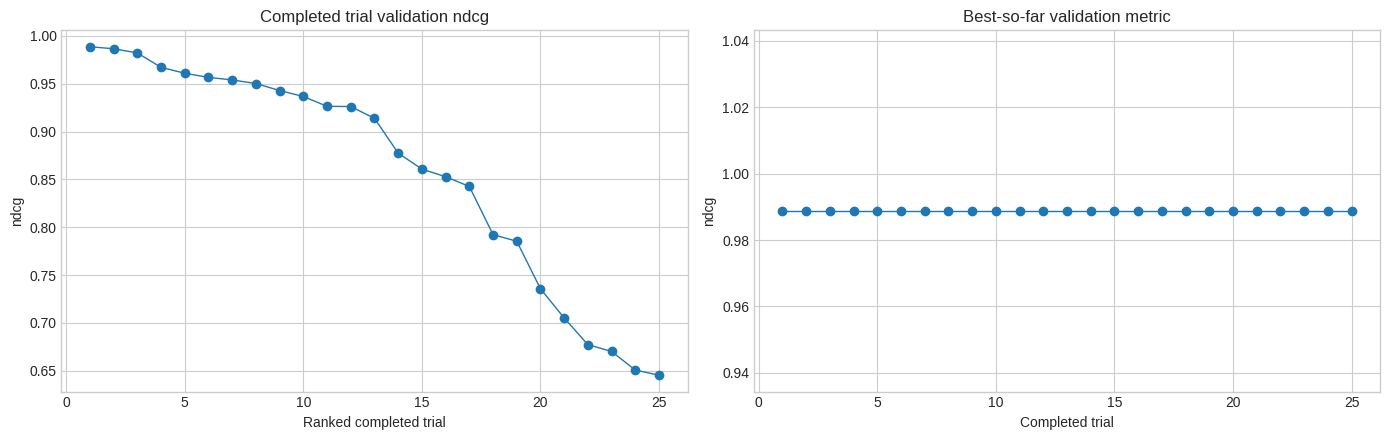

,parameter,importance
0,temporal_d_model,0.180161
1,time_window,0.167756
2,layers,0.141764
3,temporal_bptt_steps,0.134085
4,hidden_channels,0.129618
5,d,0.091211
6,weight_decay,0.050947
7,lr,0.050242
8,closure_hops,0.024247
9,stateful_temporal,0.015011


In [7]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params', 'user_attrs'))
completed_df = trials_df[trials_df['state'] == 'COMPLETE'].copy()
if not completed_df.empty:
    completed_df = completed_df.sort_values(by='value', ascending=False).reset_index(drop=True)
display(completed_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
if not completed_df.empty:
    axes[0].plot(completed_df.index + 1, completed_df['value'], marker='o', linewidth=1)
    axes[0].set_title(f'Completed trial validation {metric_name}')
    axes[0].set_xlabel('Ranked completed trial')
    axes[0].set_ylabel(metric_name)

    running_best = completed_df['value'].cummax()
    axes[1].plot(range(1, len(running_best) + 1), running_best, marker='o', linewidth=1)
    axes[1].set_title('Best-so-far validation metric')
    axes[1].set_xlabel('Completed trial')
    axes[1].set_ylabel(metric_name)
else:
    axes[0].text(0.5, 0.5, 'No completed trials yet', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No completed trials yet', ha='center', va='center')

plt.tight_layout()
plt.show()

try:
    importances = optuna.importance.get_param_importances(study)
    importance_df = pd.DataFrame(importances.items(), columns=['parameter', 'importance'])
    display(importance_df)
except Exception as exc:
    print(f'Parameter importance unavailable: {exc}')


## 5. Retrain the best configuration and evaluate it cleanly

This final pass rebuilds the snapshot bundle for the best timestamp window using `FINAL_SPLIT_CAPS`, then trains longer with a roomier patience budget.


In [8]:
best_params = dict(study.best_trial.params)
final_config = _merge_final_config(
    best_params,
    final_epochs=FINAL_EPOCHS,
    eval_every=FINAL_EVAL_EVERY,
    patience=FINAL_PATIENCE,
    min_epochs_before_stopping=FINAL_MIN_EPOCHS_BEFORE_STOPPING,
    skip_train_eval=True,
)

FINAL_SNAPSHOT_BUNDLE = _build_snapshot_bundle(
    dataset,
    temporal_data,
    node_features,
    split_edge_ids,
    FINAL_SPLIT_CAPS,
    time_window=final_config['time_window'],
)
display(_snapshot_cache_table(dataset, {final_config['time_window']: FINAL_SNAPSHOT_BUNDLE}))

final_result = _train_single_config(
    dataset_name=DATASET_NAME,
    dataset=dataset,
    snapshot_bundle=FINAL_SNAPSHOT_BUNDLE,
    node_features=node_features,
    num_nodes=num_nodes,
    output_dim=output_dim,
    device=DEVICE,
    config=final_config,
    seed=BASE_SEED,
    keep_history=True,
    trial=None,
)

final_summary = pd.DataFrame([
    {
        'split': 'train',
        metric_name: final_result['best_train_metric'],
        'loss': final_result['best_train_loss'],
        'snapshots': len(FINAL_SNAPSHOT_BUNDLE['train_snapshots']),
    },
    {
        'split': 'val',
        metric_name: final_result['best_val_metric'],
        'loss': final_result['best_val_loss'],
        'snapshots': len(FINAL_SNAPSHOT_BUNDLE['val_snapshots']),
    },
    {
        'split': 'test',
        metric_name: final_result['best_test_metric'],
        'loss': final_result['best_test_loss'],
        'snapshots': len(FINAL_SNAPSHOT_BUNDLE['test_snapshots']),
    },
])
display(_config_frame(final_config))
display(final_summary)


,time_window,window_label,train_edges,train_snapshots,train_mean_edges,train_labelled_snapshots,val_edges,val_snapshots,val_labelled_snapshots,test_edges,test_snapshots,test_labelled_snapshots
0,3,3,16384,1,16384.0,1,256,1,1,256,1,1


,field,value
0,time_window,3
1,lr,0.012488
2,weight_decay,0.0
3,hidden_channels,64
4,layers,3
5,dropout,0.0
6,d,4
7,temporal_d_model,32
8,stateful_temporal,True
9,closure_hops,2


,split,ndcg,loss,snapshots
0,train,NaN,NaN,1
1,val,0.996067,1.829892,1
2,test,0.996067,1.829892,1


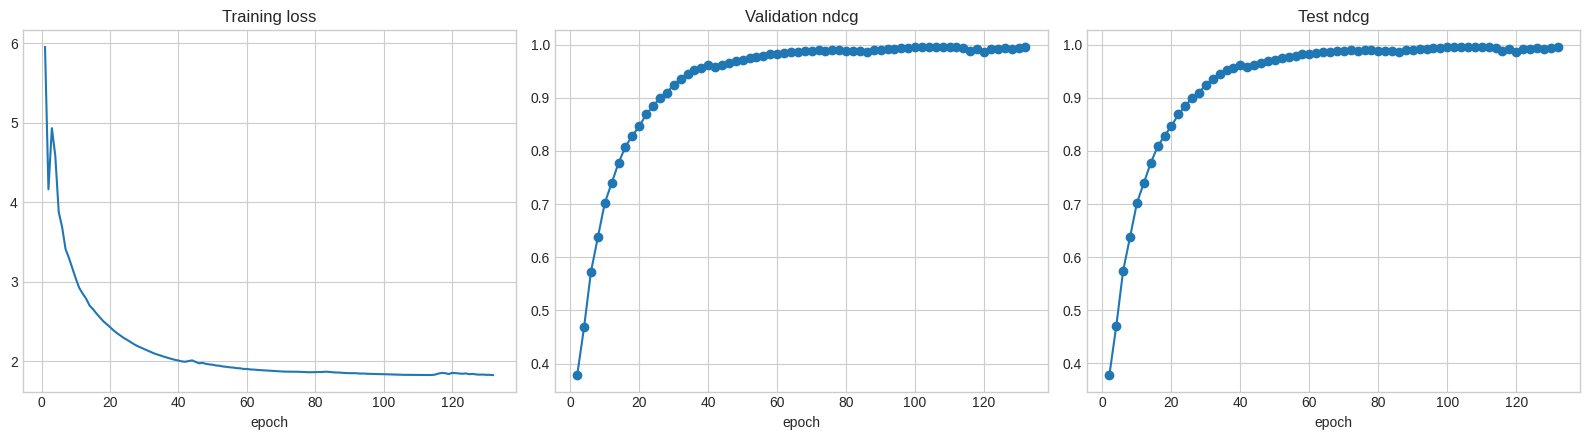

In [9]:
history_df = final_result['history'].copy()

def _find_metric_column(df, split_name, metric_name):
    preferred = [
        f'{split_name}_{metric_name}',
        f'{split_name}_{str(metric_name).lower()}',
        f'{split_name}_{str(metric_name).upper()}',
    ]
    for col in preferred:
        if col in df.columns and not df[col].isna().all():
            return col

    prefix = f'{split_name}_'
    candidates = [
        col for col in df.columns
        if col.startswith(prefix) and col not in {f'{split_name}_loss', f'{split_name}_eval_loss'} and not df[col].isna().all()
    ]
    return candidates[0] if candidates else None

val_col = _find_metric_column(history_df, 'val', metric_name)
test_col = _find_metric_column(history_df, 'test', metric_name)
eval_columns = [col for col in [val_col, test_col, 'val_loss', 'test_loss'] if col is not None and col in history_df.columns]
if eval_columns:
    eval_history_df = history_df.dropna(subset=eval_columns, how='all').copy()
else:
    eval_history_df = history_df.iloc[0:0].copy()

def _plot_metric(ax, df, column, title):
    ax.set_title(title)
    if column is None or column not in df.columns:
        ax.text(0.5, 0.5, 'Metric column not found in history', ha='center', va='center', transform=ax.transAxes)
        return

    plot_df = df[['epoch', column]].dropna().copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, 'No evaluated data to plot yet', ha='center', va='center', transform=ax.transAxes)
        return

    plot_df.plot(x='epoch', y=column, ax=ax, marker='o', linewidth=1.5, legend=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
history_df.plot(x='epoch', y='train_loss', ax=axes[0], title='Training loss', legend=False)
_plot_metric(axes[1], eval_history_df, val_col, title=f'Validation {metric_name}')
_plot_metric(axes[2], eval_history_df, test_col, title=f'Test {metric_name}')

for ax in axes:
    ax.set_xlabel('epoch')

plt.tight_layout()
plt.show()


## 6. Reproduce the final run from the command line


In [10]:
reproduction_command = _render_reproduction_command(final_config, DATASET_NAME, FINAL_SPLIT_CAPS)
display(Markdown('```bash\n' + reproduction_command + '\n```'))


```bash
export TGB_SHEAF_D=4
export TGB_LAYERS=3
export TGB_HIDDEN_CHANNELS=64
export TGB_DROPOUT=0.0
\
PYTHONPATH=. python -m exp.run_temporal \
    --dataset=tgbn-trade \
    --temporal_dataset=tgbn-trade \
    --model=TemporalMambaSheaf \
    --lr=0.012487940706903825 \
    --weight_decay=1.98417640446958e-07 \
    --stateful_temporal=True \
    --closure_hops=2 \
    --temporal_d_model=32 \
    --temporal_epochs=200 \
    --temporal_train_edges=2048 \
    --temporal_val_edges=256 \
    --temporal_test_edges=256 \
    --temporal_bptt_steps=8 \
    --temporal_snapshot_time_window=3
```